# Explore here

📝 Instrucciones
Sistema de predicción de ventas
Queremos establecer el almacén de nuestra empresa en otra localización y necesitamos estimar el ritmo de las ventas, que desde la creación de la empresa ha ido en aumento, para los próximos meses, a fin de proveer el espacio que necesitaremos.

Paso 1: Carga del conjunto de datos

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from statsmodels.tsa.arima.model import ARIMA
from pmdarima import auto_arima

import warnings
url="https://breathecode.herokuapp.com/asset/internal-link?id=2546&path=sales.csv"

df=pd.read_csv(url)

df.info()


<class 'pandas.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    366 non-null    str    
 1   sales   366 non-null    float64
dtypes: float64(1), str(1)
memory usage: 5.8 KB


convertir fecha  en formato fecha

In [2]:
df["date"] = pd.to_datetime(df["date"])
df = df.set_index("date")

df.head()

,sales
date,
2022-09-03 17:10:08.079328,55.292157
2022-09-04 17:10:08.079328,53.803211
2022-09-05 17:10:08.079328,58.141693
2022-09-06 17:10:08.079328,64.530899
2022-09-07 17:10:08.079328,66.013633


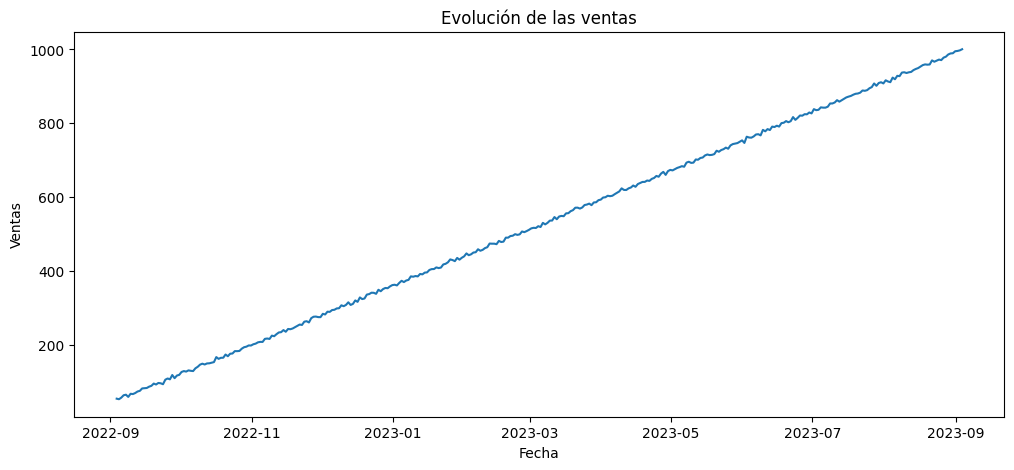

In [3]:
plt.figure(figsize=(12, 5))
plt.plot(df.index, df)
plt.title("Evolución de las ventas")
plt.xlabel("Fecha")
plt.ylabel("Ventas")
plt.show()

Conclusiones:
La serie temporal tiene una frecuencia diaria, además se visualiza una tendencia ascendente.


Paso 2: Construye y analiza la serie temporal

Descomposición de una sserie temporal, se utiliza period=30 para ver patrones cada 30 días 

In [4]:
decomposition = seasonal_decompose(df["sales"], period=30)
decomposition

Análisis de tendencia

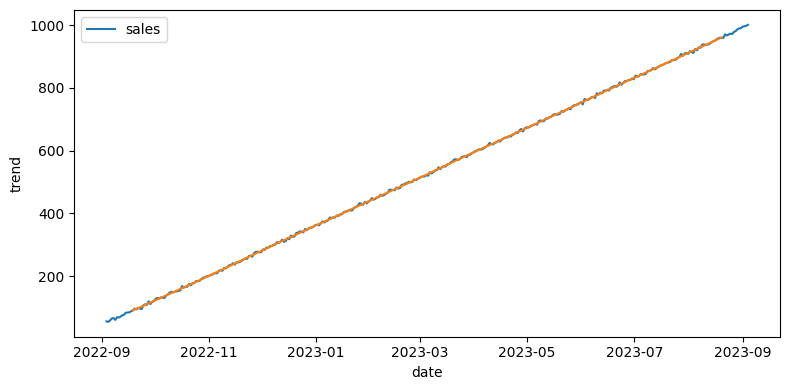

In [5]:
trend = decomposition.trend

fig, axis = plt.subplots(figsize = (8, 4))

sns.lineplot(data = df)
sns.lineplot(data = trend)

plt.tight_layout()

plt.show()

Conclusiones:

La línea naranja representa la tendencia de la serie temporal de ventas.
Se visualiza que la tendencia coincide con los datos originales de ventas, esto quiere decir que hay un crecimiento constante en ventas a lo largo del tiempo y hay poco ruido en los datos.

Análisis de estacionalidad

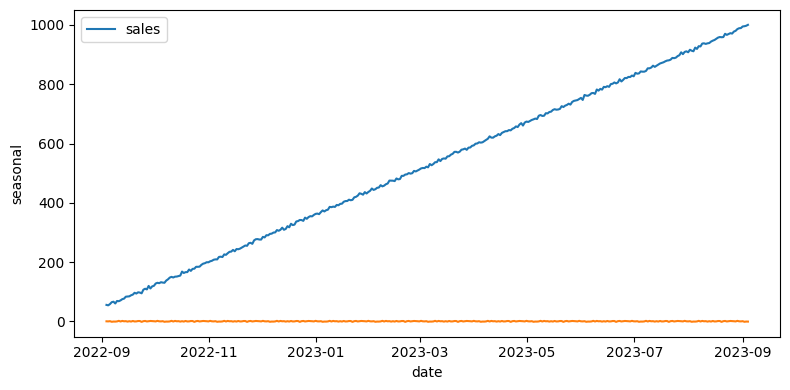

In [6]:
seasonal = decomposition.seasonal

fig, axis = plt.subplots(figsize = (8, 4))

sns.lineplot(data = df) # Representa las ventas
sns.lineplot(data = seasonal)

plt.tight_layout()

plt.show()

Conclusiones:

La estaacionalidad es muy baja por lo que se puede decir que no hay un patrón repetitivo en ventas.
En esta serie temporal predomina la tendencia ascendente. Además, hay poco ruido en los datos.

Análisis de estacionariedad

**Prueba de Dickey-Fuller** (*Dickey-Fuller test*)

In [7]:
def test_stationarity(timeseries):
    print("Resultados de la prueba de Dickey-Fuller:")
    dftest = adfuller(timeseries, autolag = "AIC")
    dfoutput = pd.Series(dftest[0:4], index = ["Test Statistic", "p-value", "#Lags Used", "Number of Observations Used"])
    for key,value in dftest[4].items():
        dfoutput["Critical Value (%s)"%key] = value
    return dfoutput

In [8]:
test_stationarity(df["sales"])

Resultados de la prueba de Dickey-Fuller:


Test Statistic                   0.545414
p-value                          0.986190
#Lags Used                      13.000000
Number of Observations Used    352.000000
Critical Value (1%)             -3.449065
Critical Value (5%)             -2.869786
Critical Value (10%)            -2.571163
dtype: float64

Conclusiones:
El valor p es mayor a 0.05 por lo que se interpreta que la serie no es estacionaria.

Paso 3: Entrena un ARIMA

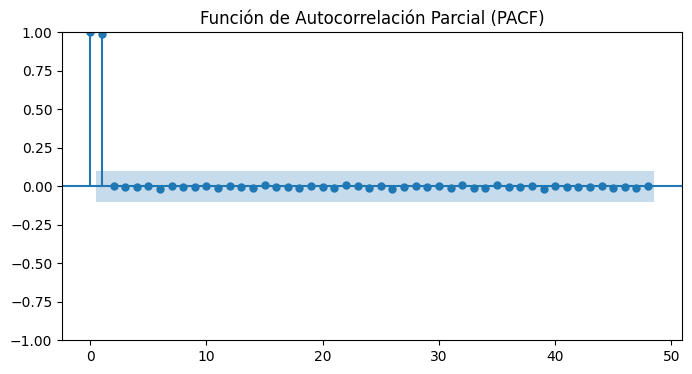

In [12]:
# Graficar PACF
plt.figure(figsize=(8, 4))
plot_pacf(df["sales"], lags=48, ax=plt.gca())
plt.title('Función de Autocorrelación Parcial (PACF)')
plt.show()

Notas:
La PACF muestra un pico significativo en el lag 1. esto significa que se sugiere utilizar el valor p=1 en el modelo arima.


In [23]:
# Diferenciación de primer orden
df_diff1 = df["sales"].diff().dropna()

Análisis ACF y PACF

- De ACF q = 1,
- De PACF p = 1.

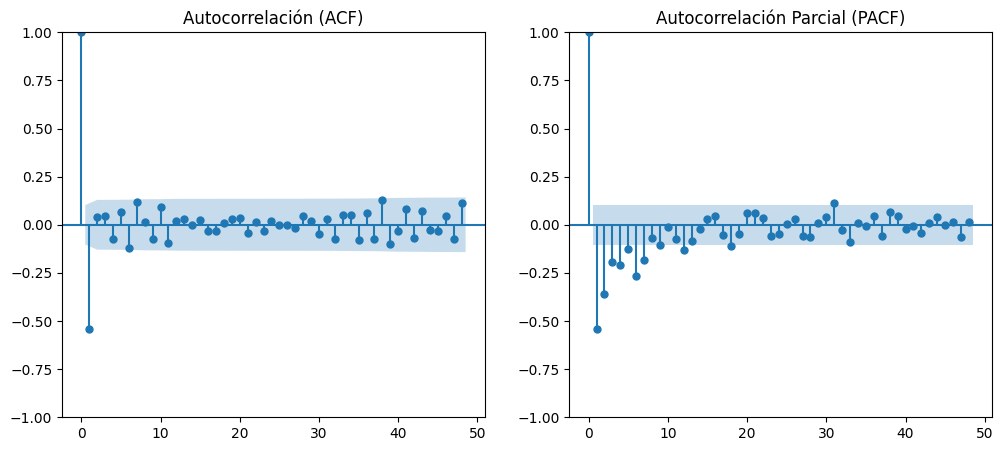

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# ACF para determinar q
plot_acf(df_diff1, lags=48, ax=ax[0])
ax[0].set_title("Autocorrelación (ACF)")

# PACF para determinar p
plot_pacf(df_diff1, lags=48, ax=ax[1])
ax[1].set_title("Autocorrelación Parcial (PACF)")

plt.show()

In [15]:
p = 1
d = 1
q = 1

modelo_arima = ARIMA(df["sales"], order=(p,d,q))

resultado_arima = modelo_arima.fit()

/home/vscode/.local/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/home/vscode/.local/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/home/vscode/.local/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


Paso 4: Predice con el conjunto de test

In [24]:
# Pronóstico para los próximos 12 meses
predicciones = resultado_arima.predict(start=len(df), end=len(df)+11)
predicciones

2023-09-04 17:10:08.079328    1003.052388
2023-09-05 17:10:08.079328    1005.621989
2023-09-06 17:10:08.079328    1008.191589
2023-09-07 17:10:08.079328    1010.761187
2023-09-08 17:10:08.079328    1013.330783
2023-09-09 17:10:08.079328    1015.900378
2023-09-10 17:10:08.079328    1018.469971
2023-09-11 17:10:08.079328    1021.039562
2023-09-12 17:10:08.079328    1023.609152
2023-09-13 17:10:08.079328    1026.178740
2023-09-14 17:10:08.079328    1028.748327
2023-09-15 17:10:08.079328    1031.317912
Freq: D, Name: predicted_mean, dtype: float64

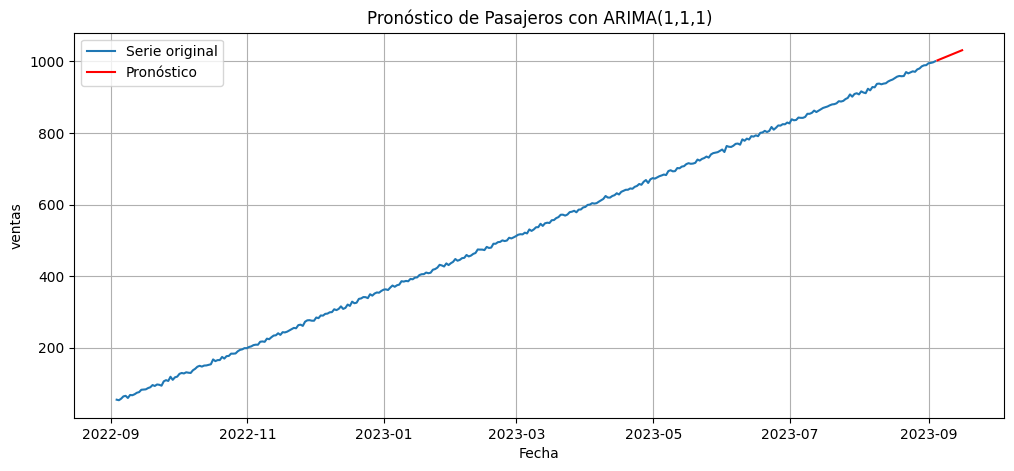

In [25]:
# Graficar pronóstico
plt.figure(figsize=(12,5))
plt.plot(df, label='Serie original')
plt.plot(predicciones, label='Pronóstico', color='red')
plt.title("Pronóstico de Pasajeros con ARIMA(1,1,1)")
plt.xlabel("Fecha")
plt.ylabel("ventas")
plt.legend()
plt.grid(True)
plt.show()

Conclusiones:


### Entrenamiento automático del modelo

In [20]:
# seasonal = True: modelo ARIMA estacional
# trace=True en auto_arima() sirve para mostrar en pantalla el proceso de búsqueda del mejor modelo ARIMA.
model = auto_arima(df, seasonal = True, trace = True, m = 12)

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[12] intercept   : AIC=1847.125, Time=4.54 sec
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=2096.542, Time=0.02 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=1972.853, Time=0.20 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=inf, Time=0.74 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=2209.657, Time=0.02 sec
 ARIMA(2,1,2)(0,0,1)[12] intercept   : AIC=1844.695, Time=1.28 sec
 ARIMA(2,1,2)(0,0,0)[12] intercept   : AIC=1843.274, Time=0.86 sec
 ARIMA(2,1,2)(1,0,0)[12] intercept   : AIC=1845.092, Time=1.16 sec
 ARIMA(1,1,2)(0,0,0)[12] intercept   : AIC=1843.586, Time=0.16 sec
 ARIMA(2,1,1)(0,0,0)[12] intercept   : AIC=1841.532, Time=0.65 sec
 ARIMA(2,1,1)(1,0,0)[12] intercept   : AIC=1843.437, Time=1.23 sec
 ARIMA(2,1,1)(0,0,1)[12] intercept   : AIC=1843.433, Time=1.21 sec
 ARIMA(2,1,1)(1,0,1)[12] intercept   : AIC=inf, Time=2.29 sec
 ARIMA(1,1,1)(0,0,0)[12] intercept   : AIC=1839.552, Time=0.18 sec
 ARIMA(1,1,1)(1,0,0)[12] inte

#### Predicción del modelo

In [21]:
forecast = model.predict(12)
forecast

2023-09-04 17:10:08.079328    1002.158148
2023-09-05 17:10:08.079328    1004.831668
2023-09-06 17:10:08.079328    1007.423289
2023-09-07 17:10:08.079328    1010.021630
2023-09-08 17:10:08.079328    1012.619419
2023-09-09 17:10:08.079328    1015.217253
2023-09-10 17:10:08.079328    1017.815084
2023-09-11 17:10:08.079328    1020.412915
2023-09-12 17:10:08.079328    1023.010746
2023-09-13 17:10:08.079328    1025.608577
2023-09-14 17:10:08.079328    1028.206408
2023-09-15 17:10:08.079328    1030.804239
Freq: D, dtype: float64

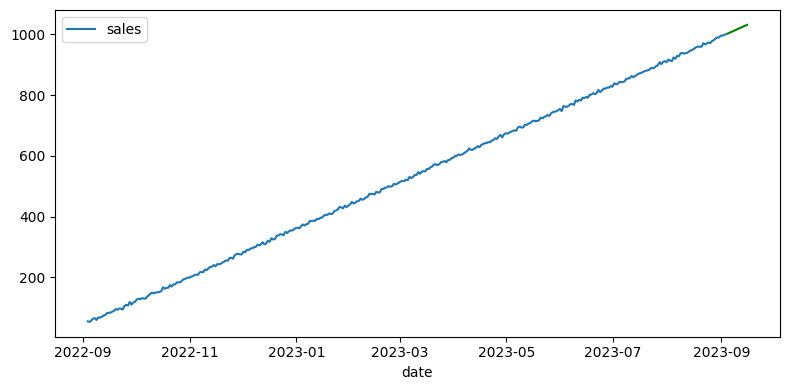

In [22]:
fig, axis = plt.subplots(figsize = (8, 4))

sns.lineplot(data = df)
sns.lineplot(data = forecast, c = "green")

plt.tight_layout()

plt.show()

Conclusiones: